## Overview
We will investigate two case studies in this seminar.
* **Sentiment polarity classification**. It is a task in natural language processing (NLP) where we analyze a product review to determine the sentiment behind it. The goal is to categorize the sentiment into different "polarities":
    * Positive: The text expresses a favorable or happy sentiment. For example, "I love this new phone! The battery life is amazing.".
    * Negative: The text expresses an unfavorable or unhappy sentiment. For example, "The hamburger does not taste great.".
    * Neutral: The text doesn't strongly convey either positive or negative sentiment. It might just be informative or factual. For example, "The event starts at 10 AM tomorrow."

* **Classification on the two moons dataset**. The "two moons" dataset is a synthetic dataset that consists of two interleaving half circles, shaped like two crescent moons. Each data point in this dataset belongs to one of two classes, class 0 and class 1. The task is to build a classifier that can accurately distinguish between the two classes, assigning the correct label to each data point.

In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import json
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer, TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split,cross_val_score,cross_validate
from sklearn.inspection import DecisionBoundaryDisplay

We begin with analyzing Amazon reviews in the Health and Personal Care category. Reviews with a rating greater than 3 are categorized as positive and assigned the label 1, whereas reviews with a rating less than 3 are categorized as negative and assigned the label -1.

In [2]:
df_health_binary = pd.read_csv("reviews_health_binary.csv", sep='\t')
y_health_binary = df_health_binary['polarity']
X_health_binary = df_health_binary.drop(columns=['polarity'])

In [5]:
df_health_binary.head()

,review,polarity
0,perfect replacement part as hoped for,1
1,Super fun game for kids and adults. Perfect p...,1
2,Works but takes time!<br />The instructions sa...,1
3,The greatest thing that has come along.,1
4,A little Balmex powder and the creme goes a lo...,1


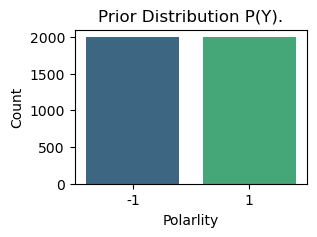

In [13]:
plt.figure(figsize=(3, 2))
sns.countplot(data=df_health_binary, x='polarity', palette='viridis')
plt.xlabel('Polarlity')
plt.ylabel('Count')
plt.title('Prior Distribution P(Y).')
plt.show()

### Text Preprocessing
A common approach is to represent each text as a numerical vector using the bag-of-words model. In this vector, the presence of a word in a document is typically indicated by a binary value (1 for presence, 0 for absence) or by a weighted value, such as TF-IDF.

**TF-IDF** stands for Term Frequency-Inverse Document Frequency. It is a statistical measure used to evaluate the importance of a word in a document relative to a corpus. The term frequency (TF) increases with the number of times a word appears in a document, while the inverse document frequency (IDF) reduces the weight of common words across the corpus. By combining these two components, TF-IDF reflects how relevant a word is to a specific document in the context of the entire dataset.
* Term Frequency: In document *d*, the frequency represents the number of instances of a given word *t*.
    ```python
        tf(t,d) = count of t in d / number of words in d
    ```
* Document Frequency: This tests the meaning of the text, which is very similar to TF, in the whole corpus collection.
    ```python
        df(t) = occurrence of t in documents
     ```
* Inverse Document Frequency: Mainly, it tests how relevant the word is.
    ```python
        idf(t) = log(N/ df(t))
    ```
* The TF-IDF weight is represented as
    ```python
        tf-idf(t, d) = tf(t, d) * idf(t)
    ```

In [21]:
X_health_train, X_health_test, y_health_train, y_health_test = train_test_split(X_health_binary, y_health_binary, test_size=0.2, random_state=42)

[CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) converts a text into either a binary BoW vector or a vector containing word counts.

In [38]:
# Represent each word appearance as a binary value.
bow_vectorizer = CountVectorizer(binary=True, max_df=0.8)

In [39]:
X_train_bow = bow_vectorizer.fit_transform(X_health_train.review)

In [18]:
X_train_bow.shape

(4000, 8904)

In [25]:
bow_vectorizer.get_feature_names_out()[:50]

array(['00', '000', '02', '02036p01', '06', '10', '100', '1000', '1000mg',
       '101', '10ml', '10yr', '10yrs', '11', '118', '11mm', '11pm', '12',
       '126', '128', '12hrs', '12oz', '13', '130', '14', '140', '15',
       '150', '1504461881', '15hr', '15ml', '16', '17', '18', '185nm',
       '19', '190', '1920s', '193', '1970s', '1975', '19mm', '1g', '1in',
       '1n', '1st', '1teaspoon', '1trill', '20', '200'], dtype=object)

[TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) converts a text into either a vector of TF-IDF values.

In [26]:
# Apply the TF-IDF weighting schema.
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8)

In [27]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_health_train.review)

In [35]:
print(X_train_tfidf[:10,:])

  (0, 7021)	0.26655724460323277
  (0, 2078)	0.26087208727448663
  (0, 2752)	0.2969588667997919
  (0, 7776)	0.28153461133444246
  (0, 7501)	0.41507156358968267
  (0, 4156)	0.352390069149966
  (0, 3385)	0.2441297305740503
  (0, 481)	0.3578753712702819
  (0, 1841)	0.41507156358968267
  (0, 2068)	0.1924188403749654
  (1, 5816)	0.6946555801055837
  (1, 6819)	0.4396478959083626
  (1, 1919)	0.49403064854633555
  (1, 3150)	0.28301425926693446
  (2, 7940)	0.525838761037466
  (2, 4866)	0.8505842682477632
  (3, 2372)	0.1466083822281859
  (3, 7202)	0.13500360572394154
  (3, 2757)	0.30641328278098223
  (3, 4660)	0.2662334629354237
  (3, 4105)	0.1485087186535041
  (3, 1139)	0.16086339812575828
  (3, 4947)	0.2662334629354237
  (3, 7603)	0.2915841067691275
  (3, 1834)	0.30641328278098223
  :	:
  (7, 5028)	0.20507352967443904
  (7, 3200)	0.09938432719990181
  (7, 3150)	0.10963965680887573
  (8, 4519)	0.160700787190644
  (8, 7725)	0.17513035967500376
  (8, 1707)	0.27600436840252596
  (8, 7861)	0.1991675

In [30]:
for word, idf in list(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))[:20]:
    print(word, ':', idf)

00 : 7.12530839091455
000 : 7.9726062513017535
02 : 8.378071359409919
02036p01 : 8.378071359409919
06 : 8.378071359409919
10 : 5.159195534541717
100 : 6.02669610224644
1000 : 7.684924178849973
1000mg : 7.684924178849973
101 : 7.9726062513017535
10ml : 7.9726062513017535
10yr : 8.378071359409919
10yrs : 8.378071359409919
11 : 6.8739939626336435
118 : 8.378071359409919
11mm : 8.378071359409919
11pm : 8.378071359409919
12 : 6.238005195913647
126 : 8.378071359409919
128 : 8.378071359409919


In [ ]:
metrics = ['precision_micro', 'recall_micro','f1_micro']

In [57]:
svm_linear = SVC(kernel='linear', C=10, random_state=42)
default_svm_linear = svm_linear.fit(X_train_bow, y_health_train)

In [58]:
svm_linear.n_support_

array([564, 540])

Classification Report:
              precision    recall  f1-score   support

          -1       0.82      0.79      0.80       378
           1       0.82      0.84      0.83       422

    accuracy                           0.82       800
   macro avg       0.82      0.81      0.82       800
weighted avg       0.82      0.82      0.82       800



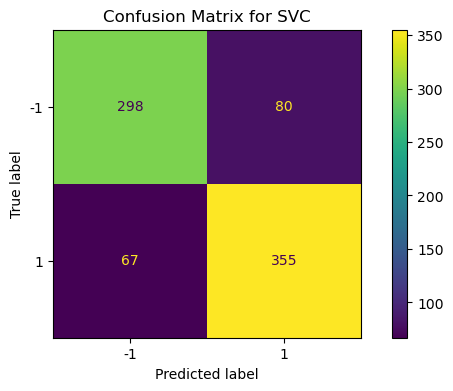

In [85]:
X_test_bow = bow_vectorizer.transform(X_health_test.review)
predictions_bow = default_svm_linear.predict(X_test_bow)
report = classification_report(y_health_test, predictions_bow)
print(f'Classification Report:\n{report}')
fig, ax = plt.subplots(figsize=(8, 4))
ConfusionMatrixDisplay.from_predictions(y_health_test, predictions_bow, ax=ax)
ax.xaxis.set_ticklabels(default_svm_linear.classes_)
ax.yaxis.set_ticklabels(default_svm_linear.classes_)
_ = ax.set_title(
    f"Confusion Matrix for {default_svm_linear.__class__.__name__}"
)

In [59]:
scores_svm_linear = cross_validate(svm_linear, X_train_bow, y_health_train, cv=5, scoring=metrics)
print("Precision: %0.4f ; Recall : %0.4f ; F1 : %0.4f" % (scores_svm_linear['test_precision_micro'].mean(), scores_svm_linear['test_recall_micro'].mean(), scores_svm_linear['test_f1_micro'].mean()))

Precision: 0.8153 ; Recall : 0.8153 ; F1 : 0.8153


#### What are the best possible cost *C*?

In [53]:
cost_range = 10.0 ** np.arange(-2, 2, 0.25)
cost_range

array([1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
       1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
       1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
       1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01])

In [100]:
def random_search_hyperparams(model, X, y, params={"C": cost_range}, n_iter = 10):
    rnd_search_svm = RandomizedSearchCV(model, param_distributions = params, n_iter = n_iter, cv = 5, random_state=40)
    rnd_search_svm.fit(X, y)
    print("best hyper-parameters : ", rnd_search_svm.best_params_)
    best_model = rnd_search_svm.best_estimator_
    print("Number of support vectors : ", best_model.n_support_)
    return rnd_search_svm

In [66]:
rnd_search_svm_linear = random_search_hyperparams(svm_linear, X_train_bow, y_health_train)

best hyper-parameters :  {'C': 0.05623413251903491}
Number of support vectors :  [898 869]


In [67]:
svm_linear_best = SVC(kernel='linear', C=rnd_search_svm_linear.best_params_['C'], random_state=40)
scores_svm_linear_best = cross_validate(svm_linear_best, X_train_bow, y_health_train, cv=5, scoring=metrics)
print("Precision: %0.4f ; Recall : %0.4f ; F1 : %0.4f" % (scores_svm_linear_best['test_precision_micro'].mean(), scores_svm_linear_best['test_recall_micro'].mean(), scores_svm_linear_best['test_f1_micro'].mean()))

Precision: 0.8497 ; Recall : 0.8497 ; F1 : 0.8497


Identify the best possible hyperparameter C for the linear SVM and compute the cross-validation errors on the dataset using TF-IDF weights.

In [70]:
rnd_search_svm_tfidf = random_search_hyperparams(svm_linear, X_train_tfidf, y_health_train)
svm_linear_bow_best = SVC(kernel='linear', C=rnd_search_svm_tfidf.best_params_['C'], random_state=40)

best hyper-parameters :  {'C': 1.7782794100389228}
Number of support vectors :  [984 935]


In [71]:
svm_linear_best = SVC(kernel='linear', C=rnd_search_svm_tfidf.best_params_['C'], random_state=40)
scores_svm_tfidf = cross_validate(svm_linear_best, X_train_tfidf, y_health_train, cv=5, scoring=metrics)
print("Precision: %0.4f ; Recall : %0.4f ; F1 : %0.4f" % (scores_svm_tfidf['test_precision_micro'].mean(), scores_svm_tfidf['test_recall_micro'].mean(), scores_svm_tfidf['test_f1_micro'].mean()))

Precision: 0.8197 ; Recall : 0.8197 ; F1 : 0.8197


### Non-Linear Classification with SVM.

#### Application of RBF kernel.

In [77]:
svm_rbf = SVC(kernel='rbf', C=0.05623413251903491, gamma='auto', random_state=42)
rnd_search_svm_rbf = random_search_hyperparams(svm_rbf, X_train_bow, y_health_train)

best hyper-parameters :  {'C': 56.23413251903491}
Number of support vectors :  [1124 1102]


In [78]:
svm_rbf = SVC(kernel='rbf', C=56.23413251903491, gamma='auto', random_state=42)
scores_svm_rbf = cross_validate(svm_rbf, X_train_bow, y_health_train, cv=5, scoring=metrics)
print("Precision: %0.4f ; Recall : %0.4f ; F1 : %0.4f" % (scores_svm_rbf['test_precision_micro'].mean(), scores_svm_rbf['test_recall_micro'].mean(), scores_svm_rbf['test_f1_micro'].mean()))

Precision: 0.8344 ; Recall : 0.8344 ; F1 : 0.8344


Identify the best possible hyperparameters (C and degree) with the polynomial kernel.
```python
    Specify params={"C": cost_range, "degree":[2,3,4]} in random_search_hyperparams()
```
You may increase the number of iterations by setting n_iter to a higher number.

In [79]:
svm_poly = SVC(kernel='poly', C=0.05623413251903491, degree=2, random_state=42)
rnd_search_svm_poly = random_search_hyperparams(svm_poly, X_train_bow, y_health_train, params={"C": cost_range, "degree":[2,3]})

best hyper-parameters :  {'degree': 2, 'C': 31.622776601683793}
Number of support vectors :  [ 994 1001]


In [80]:
svm_poly = SVC(kernel='poly', C=31.622776601683793, degree=2, random_state=42)
scores_svm_poly = cross_validate(svm_poly, X_train_bow, y_health_train, cv=5, scoring=metrics)
print("Precision: %0.4f ; Recall : %0.4f ; F1 : %0.4f" % (scores_svm_poly['test_precision_micro'].mean(), scores_svm_poly['test_recall_micro'].mean(), scores_svm_poly['test_f1_micro'].mean()))

Precision: 0.8234 ; Recall : 0.8234 ; F1 : 0.8234


### Case study 2: Non-Linear Classification on the two moons dataset.

Generate the dataset and split the dataset into the training and the validation set.

In [87]:
X_moon, y_moon = make_moons (n_samples = 500, noise = 0.15, random_state = 49)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(X_moon, y_moon, test_size=0.2,
                                                    random_state=42)

In [88]:
def plot_moon_data(X,y):
    h = 0.2 # step size in the mesh
    _, ax = plt.subplots(figsize=(6, 4))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Labels")
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title("Two Moons")
    plt.show()

In [89]:
def plot_svm (cls_model, X, y, support_vectors=True):
    """
    Generate a plot of SVM including the decision boundary, margin, and its training data
    
    Parameters
    ----------
    cls_model: your classifier handle
    X: feature matrix shape(m_samples, n_features)
    y: label vector shape(m_samples, )
    axes: (optional) the axes of the plot in format [xmin, xmax, ymin, ymax] 
    """
    
    _, ax = plt.subplots(figsize=(6, 4))
    h = 0.2 # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Labels")
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title("Two Moons")
    
    common_params = {"estimator": cls_model, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )
    

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            cls_model.support_vectors_[:, 0],
            cls_model.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )
    plt.show()

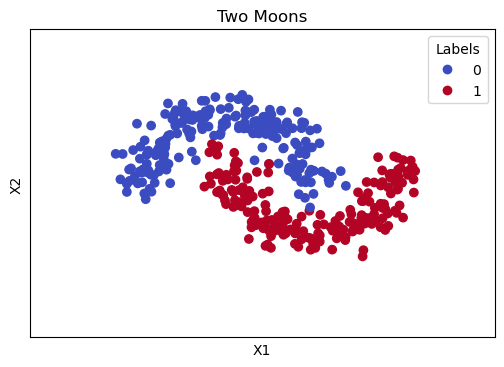

In [90]:
plot_moon_data(X_moon_train, y_moon_train)

Train an SVM with linear kernel, visualise it and evaluate it on the test set.

In [97]:
svm_linear_moon = SVC(kernel='linear', C=1, random_state=42)
rnd_search_svm_linear = random_search_hyperparams(svm_linear_moon,X_moon_train, y_moon_train)

best hyper-parameters :  {'C': 17.78279410038923}
Number of support vectors :  [53 52]


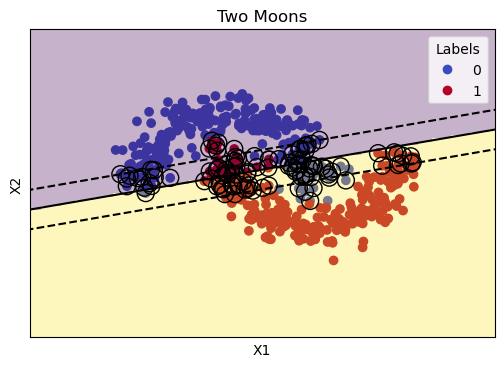

In [99]:
svm_linear_moon = SVC(kernel='linear', C=17.78279410038923, random_state=42)
svm_linear_moon_model = svm_linear_moon.fit(X_moon_train, y_moon_train)
plot_svm(svm_linear_moon_model, X_moon, y_moon, support_vectors = True)

In [105]:
# Evaluate the SVM with linear kernel on the test set.
pred_linear = svm_linear_moon_model.predict(X_moon_test)
report_linear = classification_report(y_moon_test, pred_linear)
print(f'Classification Report:\n{report_linear}')

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        45
           1       0.82      0.91      0.86        55

    accuracy                           0.84       100
   macro avg       0.85      0.83      0.84       100
weighted avg       0.84      0.84      0.84       100



Train an SVM with RBF kernel, visualize the trained model, and evaluate it on the test set. 

In [93]:
# Search the best possible C for the rbf kernel.
svm_rbf_moon = SVC(kernel='rbf', C=1, gamma='auto', random_state=42)
rnd_search_svm_rbf = random_search_hyperparams(svm_rbf_moon,X_moon_train, y_moon_train)

best hyper-parameters :  {'C': 17.78279410038923}
Number of support vectors :  [17 16]


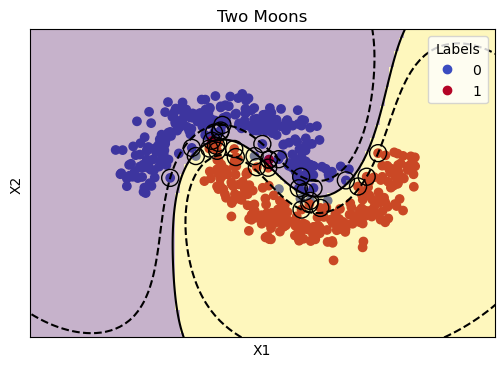

In [94]:
# Visualize the best svm with the RBF kernel.
svm_rbf_moon = SVC(kernel='rbf', C=17.78279410038923, gamma='auto', random_state=42)
svm_rbf_moon_model = svm_rbf_moon.fit(X_moon_train, y_moon_train)
plot_svm(svm_rbf_moon_model, X_moon, y_moon, support_vectors = True)

In [95]:
# Evaluate the SVM with RBF kernel on the test set.
pred_rbf = svm_rbf_moon_model.predict(X_moon_test)
report_rbf = classification_report(y_moon_test, pred_rbf)
print(f'Classification Report:\n{report_rbf}')

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        45
           1       0.95      1.00      0.97        55

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



Train an SVM with polynomial kernel, visualise it and evaluate it on the test set.

In [101]:
svm_poly_moon = SVC(kernel='poly', C=0.05623413251903491, degree=2, random_state=42)
rnd_search_svm_poly_moon = random_search_hyperparams(svm_poly_moon, X_moon_train, y_moon_train, params={"C": cost_range, "degree":[2,3,4]}, n_iter=20)

best hyper-parameters :  {'degree': 3, 'C': 0.1778279410038923}
Number of support vectors :  [79 78]


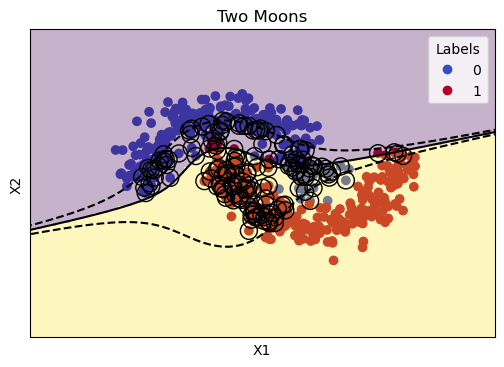

In [102]:
svm_poly_moon = SVC(kernel='poly', C=0.1778279410038923, degree=3, random_state=42)
svm_poly_model_moon = svm_poly_moon.fit(X_moon_train, y_moon_train)
plot_svm(svm_poly_model_moon, X_moon, y_moon)

In [103]:
# Evaluate the SVM with polynomial kernel on the test set.
pred_poly = svm_poly_model_moon.predict(X_moon_test)
report_poly = classification_report(y_moon_test, pred_poly)
print(f'Classification Report:\n{report_poly}')

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        45
           1       0.86      1.00      0.92        55

    accuracy                           0.91       100
   macro avg       0.93      0.90      0.91       100
weighted avg       0.92      0.91      0.91       100

